In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
df = pd.read_csv("/content/creditcard.csv")

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (162557, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

    

In [ ]:
print("Total Missing Values:", df.isnull().sum().sum())

Total Missing Values: 3


In [ ]:
df = df.dropna()

In [ ]:
X = df.drop(columns=["Class"])
y = df["Class"]

print("Input Shape:", X.shape)
print("Target Shape:", y.shape)

Input Shape: (162556, 30)
Target Shape: (162556,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (130044, 30)
Testing Data: (32512, 30)


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
l1_model = LogisticRegression(
    penalty="l1",
    solver="liblinear",
    C=1,
    max_iter=1000
)

l1_model.fit(X_train, y_train)

y_pred_l1 = l1_model.predict(X_test)

In [ ]:
l1_accuracy = accuracy_score(y_test, y_pred_l1)
l1_precision = precision_score(y_test, y_pred_l1)
l1_recall = recall_score(y_test, y_pred_l1)
l1_f1 = f1_score(y_test, y_pred_l1)

print("========== L1 REGULARIZATION ==========")

print("Accuracy:", l1_accuracy)
print("Accuracy Percentage:", l1_accuracy * 100, "%")
print("Precision:", l1_precision)
print("Recall:", l1_recall)
print("F1 Score:", l1_f1)

========== L1 REGULARIZATION ==========
Accuracy: 0.9988927165354331
Accuracy Percentage: 99.8892716535433 %
Precision: 0.8070175438596491
Recall: 0.647887323943662
F1 Score: 0.71875


In [ ]:
l2_model = LogisticRegression(
    penalty="l2",
    solver="liblinear",
    C=1,
    max_iter=1000
)

l2_model.fit(X_train, y_train)

y_pred_l2 = l2_model.predict(X_test)

In [ ]:
l2_accuracy = accuracy_score(y_test, y_pred_l2)
l2_precision = precision_score(y_test, y_pred_l2)
l2_recall = recall_score(y_test, y_pred_l2)
l2_f1 = f1_score(y_test, y_pred_l2)

print("========== L2 REGULARIZATION ==========")

print("Accuracy:", l2_accuracy)
print("Accuracy Percentage:", l2_accuracy * 100, "%")
print("Precision:", l2_precision)
print("Recall:", l2_recall)
print("F1 Score:", l2_f1)

========== L2 REGULARIZATION ==========
Accuracy: 0.9989234744094488
Accuracy Percentage: 99.89234744094489 %
Precision: 0.8103448275862069
Recall: 0.6619718309859155
F1 Score: 0.7286821705426356


In [ ]:
 comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "L1": [
        l1_accuracy,
        l1_precision,
        l1_recall,
        l1_f1
    ],
    "L2": [
        l2_accuracy,
        l2_precision,
        l2_recall,
        l2_f1
    ]
})

print(comparison)

      Metric        L1        L2
0   Accuracy  0.998893  0.998923
1  Precision  0.807018  0.810345
2     Recall  0.647887  0.661972
3   F1 Score  0.718750  0.728682


In [ ]:
cm_l1 = confusion_matrix(y_test, y_pred_l1)

print("L1 Confusion Matrix:")
print(cm_l1)

L1 Confusion Matrix:
[[32430    11]
 [   25    46]]


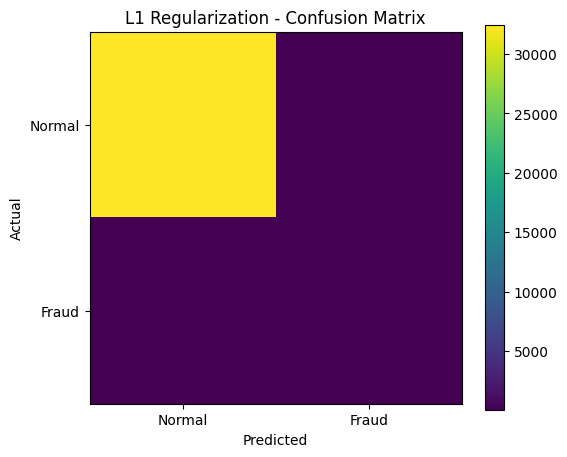

In [ ]:
plt.figure(figsize=(6, 5))

plt.imshow(cm_l1)

plt.title("L1 Regularization - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

plt.xticks([0, 1], ["Normal", "Fraud"])
plt.yticks([0, 1], ["Normal", "Fraud"])

plt.show()

In [ ]:
cm_l2 = confusion_matrix(y_test, y_pred_l2)

print("L2 Confusion Matrix:")
print(cm_l2)

L2 Confusion Matrix:
[[32430    11]
 [   24    47]]


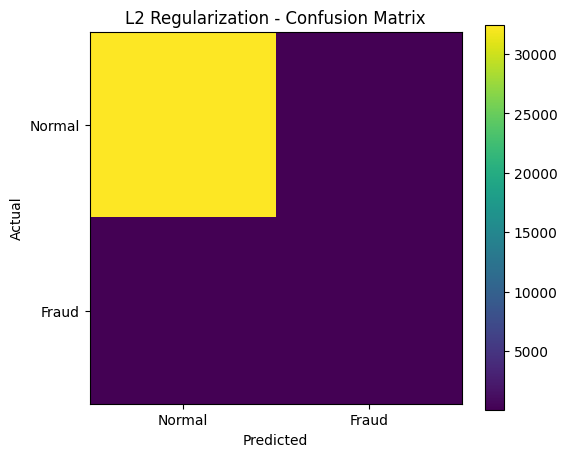

In [ ]:
plt.figure(figsize=(6, 5))

plt.imshow(cm_l2)

plt.title("L2 Regularization - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.colorbar()

plt.xticks([0, 1], ["Normal", "Fraud"])
plt.yticks([0, 1], ["Normal", "Fraud"])

plt.show()